# Exploratory Data Analysis

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

path = os.getcwd()
df = pd.read_csv( path+"//dmt_data.csv", index_col=False )

In [60]:
display( df.head() )

,DMT-Previous Experiences,Mean-PSD-pre-alpha,Mean-PSD-pre-beta,Mean-PSD-pre-delta,Mean-PSD-pre-gamma1,Mean-PSD-pre-gamma2,Mean-PSD-pre-theta,Mean-PSD-dmt-alpha,Mean-PSD-dmt-beta,Mean-PSD-dmt-delta,Mean-PSD-dmt-gamma1,Mean-PSD-dmt-gamma2,Mean-PSD-dmt-theta,Coherence-P8-Cz-beta,Coherence-P8-Pz-beta,Coherence-F7-Cz-gamma1,Coherence-F8-Pz-gamma1,Coherence-F8-POz-gamma1,Coherence-M1-CPz-gamma2,Mean-spectral-entropy
0,1,0.669,0.036,0.152,0.009,0.004,0.100,0.465,0.060,0.278,0.022,0.018,0.126,0.040,0.040,0.030,0.029,0.021,0.018,3.874
1,1,0.403,0.085,0.351,0.009,0.007,0.116,0.234,0.100,0.431,0.035,0.031,0.140,0.055,0.066,0.016,0.006,0.014,0.018,4.348
2,1,0.234,0.127,0.355,0.043,0.028,0.184,0.117,0.103,0.538,0.023,0.013,0.177,0.079,0.082,0.012,0.024,0.047,0.014,4.191
3,1,0.284,0.044,0.414,0.011,0.006,0.211,0.063,0.069,0.577,0.039,0.037,0.185,0.036,0.014,0.035,0.046,0.042,0.009,3.970
4,0,0.425,0.051,0.314,0.024,0.023,0.133,0.203,0.060,0.474,0.045,0.040,0.148,0.001,0.004,0.023,0.008,0.029,0.000,4.559


In [61]:
y = df['DMT-Previous Experiences']
X = df.drop( columns='DMT-Previous Experiences' )

# Correlations

,Mean-PSD-pre-alpha,Mean-PSD-pre-beta,Mean-PSD-pre-delta,Mean-PSD-pre-gamma1,Mean-PSD-pre-gamma2,Mean-PSD-pre-theta,Mean-PSD-dmt-alpha,Mean-PSD-dmt-beta,Mean-PSD-dmt-delta,Mean-PSD-dmt-gamma1,Mean-PSD-dmt-gamma2,Mean-PSD-dmt-theta,Coherence-P8-Cz-beta,Coherence-P8-Pz-beta,Coherence-F7-Cz-gamma1,Coherence-F8-Pz-gamma1,Coherence-F8-POz-gamma1,Coherence-M1-CPz-gamma2,Mean-spectral-entropy
Point-Biserial Correlation,0.203537,0.221899,-0.219093,-0.190525,-0.271034,-0.065712,-0.073884,0.286512,0.091009,-0.064476,-0.070584,-0.120048,0.513154,0.504135,0.252994,0.508922,0.439731,0.514933,0.115095


,Mean-PSD-pre-alpha,Mean-PSD-pre-beta,Mean-PSD-pre-delta,Mean-PSD-pre-gamma1,Mean-PSD-pre-gamma2,Mean-PSD-pre-theta,Mean-PSD-dmt-alpha,Mean-PSD-dmt-beta,Mean-PSD-dmt-delta,Mean-PSD-dmt-gamma1,Mean-PSD-dmt-gamma2,Mean-PSD-dmt-theta,Coherence-P8-Cz-beta,Coherence-P8-Pz-beta,Coherence-F7-Cz-gamma1,Coherence-F8-Pz-gamma1,Coherence-F8-POz-gamma1,Coherence-M1-CPz-gamma2,Mean-spectral-entropy
p-value,0.29888,0.256433,0.262649,0.331483,0.162997,0.739721,0.708669,0.139368,0.645103,0.744456,0.721155,0.542868,0.005229,0.00623,0.193967,0.00568,0.019208,0.005049,0.559758


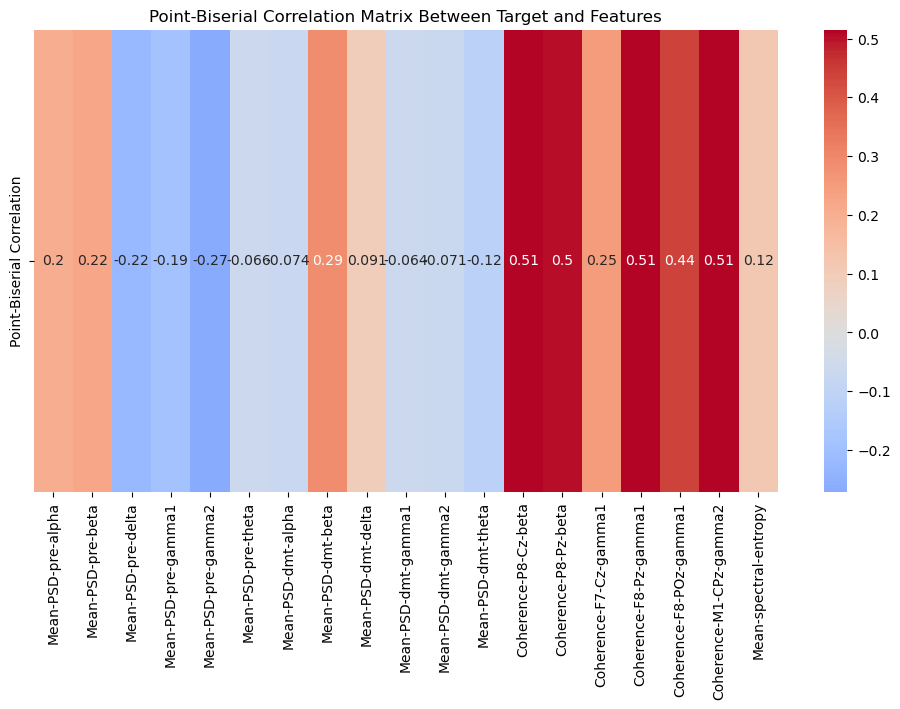

In [62]:
from scipy.stats import pointbiserialr
import seaborn as sns

correlations = {}
p_values = {}

for col in X.columns:
    corr, p_value = pointbiserialr( y, df[col] )
    correlations[col] = corr
    p_values[col] = p_value

corr = pd.DataFrame( correlations, index=['Point-Biserial Correlation'] )
corr_p_value = pd.DataFrame( p_values, index=['p-value'] )
display( corr )
display( corr_p_value )

plt.figure( figsize=(12, 6) )
sns.heatmap( corr, annot=True, cmap='coolwarm', center=0 )
plt.title( 'Point-Biserial Correlation Matrix Between Target and Features' )
plt.show()


# 1. Logistic Regression

# 1.1 Model Selection and Hyperparameter Tuning

In [63]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split( X.values, y.values, test_size=0.2, stratify=y, random_state=42 )
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform( X_train )
X_test_scaled = scaler.transform( X_test )

logreg = LogisticRegression( solver='liblinear', max_iter=10000, random_state=42 )
logreg.fit( X_train_scaled, y_train )
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
    }

grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
    )

grid_search.fit( X_train_scaled, y_train )
best_params = grid_search.best_params_
print( f"Best parameters: {best_params}" )


Best parameters: {'C': 10, 'penalty': 'l2'}


In [64]:
best_log_reg = LogisticRegression( **best_params, random_state=42 )
best_log_reg.fit( X_train_scaled, y_train )

LogisticRegression(C=10, random_state=42)

# 1.2 Evaluate model performance

In [65]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

y_pred = best_log_reg.predict( X_test_scaled )
y_pred_proba = best_log_reg.predict_proba( X_test_scaled )[:, 1]
confusion = confusion_matrix( y_test, y_pred )
print( f"Confusion matrix: \n{confusion}" )
print()
print( classification_report( y_test, y_pred, target_names=['one-time', 'multiple-time'] ) )

Confusion matrix: 
[[1 1]
 [0 4]]

               precision    recall  f1-score   support

     one-time       1.00      0.50      0.67         2
multiple-time       0.80      1.00      0.89         4

     accuracy                           0.83         6
    macro avg       0.90      0.75      0.78         6
 weighted avg       0.87      0.83      0.81         6



# 1.3 Visualize results

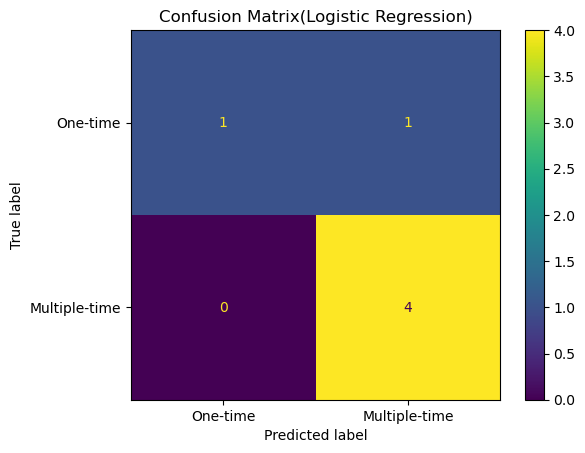

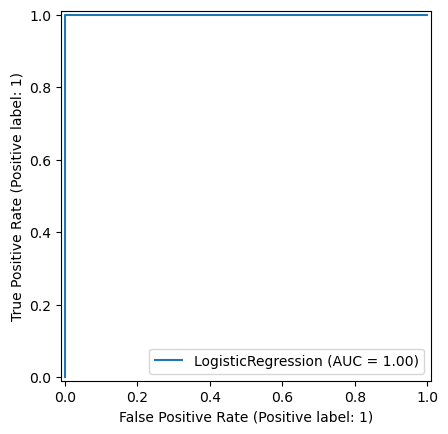

In [66]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve, RocCurveDisplay, ConfusionMatrixDisplay

confusion_disp = ConfusionMatrixDisplay( confusion_matrix=confusion, 
                                        display_labels=['One-time', 'Multiple-time'] )
confusion_disp.plot()
plt.title( 'Confusion Matrix(Logistic Regression)' )
plt.show()

fpr, tpr, thresholds = roc_curve( y_test, y_pred_proba )
roc_auc = auc( fpr, tpr )
RocCurveDisplay.from_estimator( best_log_reg, X_test_scaled, y_test )
plt.show()


# 1.4 Feature Importance Analysis

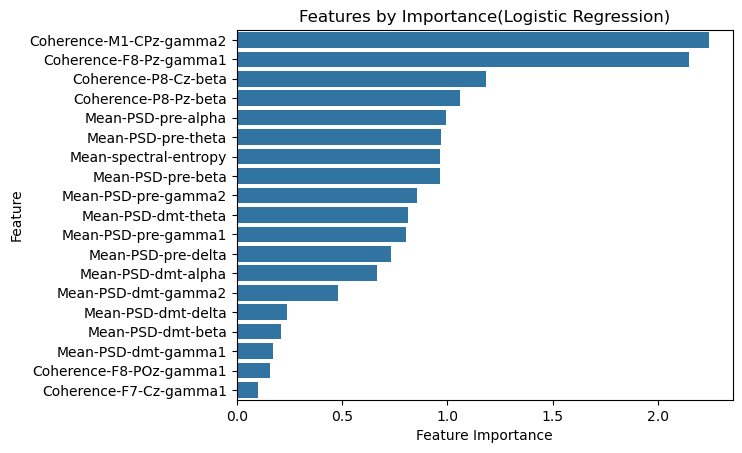

In [85]:
import seaborn as sns

coefficients = best_log_reg.coef_[0]
feature_importance = pd.DataFrame( {'Feature': X.columns, 'Coefficient': coefficients} )
feature_importance['Abs_Coefficient'] = abs( feature_importance['Coefficient'] )
feature_importance = feature_importance.sort_values( 'Abs_Coefficient', ascending=False )

sns.barplot( y='Feature', x='Abs_Coefficient', data=feature_importance )
plt.title( 'Features by Importance(Logistic Regression)' )
plt.xlabel( "Feature Importance" )
plt.show()

# 1.5 Statistical Significance Testing

In [68]:
# from sklearn.model_selection import permutation_test_score

# # Perform permutation test
# score, perm_scores, pvalue = permutation_test_score(
#     best_log_reg, X_train_scaled, y_train, 
#     scoring="accuracy", cv=5, n_permutations=1000
# )

# print(f"Model accuracy: {score:.4f}")
# print(f"Permutation accuracy scores mean: {perm_scores.mean():.4f}")
# print(f"P-value: {pvalue:.4f}")

# # Plot permutation test results
# plt.figure(figsize=(10, 6))
# plt.hist(perm_scores, bins=20, edgecolor='black')
# plt.axvline(score, color='red', linestyle='--', label=f'Accuracy = {score:.4f}')
# plt.xlabel('Accuracy')
# plt.ylabel('Frequency')
# plt.title('Permutation Test Results')
# plt.legend()
# plt.show()

# 2. Support Vector Machine(SVM)

# 2.1 Model Selection and Hyperparameter Tuning

In [69]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid_svc = [
    {'kernel': ['linear'], 'C': [0.01, 0.1, 1, 10, 100]},
    {'kernel': ['rbf'], 'C': [0.01, 0.1, 1, 10, 100], 'gamma': [0.01, 0.1, 1, 10]}
]

grid_search_svc = GridSearchCV(
    SVC( probability=True, random_state=42 ),
    param_grid=param_grid_svc,
    cv=5,
    scoring='accuracy'
)

grid_search_svc.fit(X_train_scaled, y_train)

best_params_svc = grid_search_svc.best_params_
print(f"Best parameters: {best_params_svc}")

best_svm = grid_search_svc.best_estimator_

Best parameters: {'C': 1, 'kernel': 'linear'}


# 2.2 Model Evaluation

In [78]:
y_pred_svm = best_svm.predict( X_test_scaled )
y_pred_proba_svm = best_svm.predict_proba( X_test_scaled )[:, 1]
confusion = confusion_matrix( y_test, y_pred_svm )
print( f"Confusion matrix: \n{confusion}" )
print()
print( classification_report( y_test, y_pred_svm, target_names=['one-time', 'multiple-time'] ) )

Confusion matrix: 
[[1 1]
 [0 4]]

               precision    recall  f1-score   support

     one-time       1.00      0.50      0.67         2
multiple-time       0.80      1.00      0.89         4

     accuracy                           0.83         6
    macro avg       0.90      0.75      0.78         6
 weighted avg       0.87      0.83      0.81         6



# 2.3 Visualizaton of Results

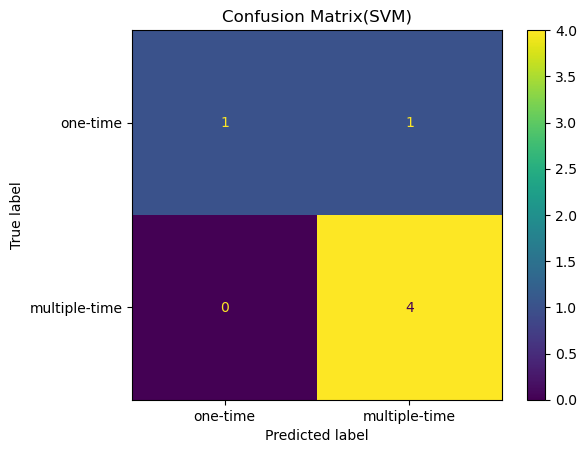

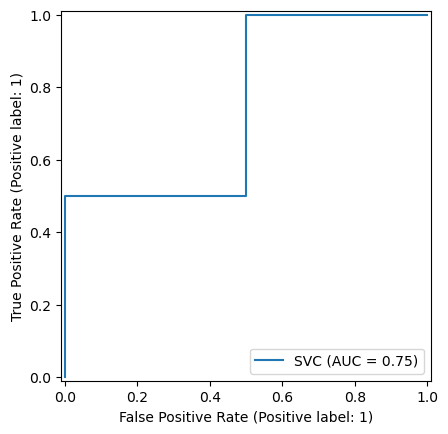

In [79]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve, RocCurveDisplay, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator( best_svm, X_test_scaled, y_test, display_labels=['one-time', 'multiple-time'] )
plt.title( 'Confusion Matrix(SVM)' )
plt.show()

fpr, tpr, thresholds = roc_curve( y_test, y_pred_proba_svm )
roc_auc = auc( fpr, tpr )
RocCurveDisplay.from_estimator( best_svm, X_test_scaled, y_test )
plt.show()

# 2.4 Feature Importance Analysis

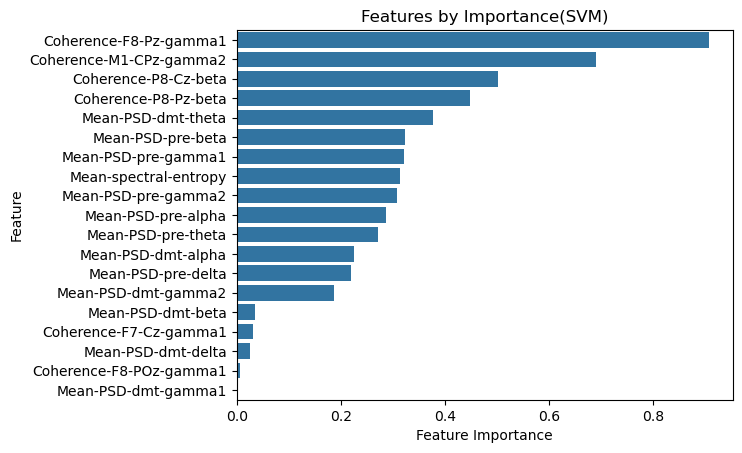

In [84]:
import seaborn as sns

coefficients = best_svm.coef_[0]
feature_importance = pd.DataFrame( {'Feature': X.columns, 'Coefficient': coefficients} )
feature_importance['Abs_Coefficient'] = abs( feature_importance['Coefficient'] )
feature_importance = feature_importance.sort_values( 'Abs_Coefficient', ascending=False )

sns.barplot( y='Feature', x='Abs_Coefficient', data=feature_importance )
plt.title( 'Features by Importance(SVM)' )
plt.xlabel( "Feature Importance" )
plt.show()

# 3. Random Forest

# 3.1 Model Selection and Hyperparameter Tuning

In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier( random_state=42 )
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs = -1
)

grid_search_rf.fit( X_train_scaled, y_train )

best_params_rf = grid_search_rf.best_params_
print(f"Best parameters: {best_params_rf}")

best_rf = grid_search_rf.best_estimator_

Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}


# 3.2 Model Evaluation

In [80]:
y_pred_rf = best_rf.predict( X_test_scaled )
y_pred_proba_rf = best_rf.predict_proba( X_test_scaled )[:, 1]
confusion = confusion_matrix( y_test, y_pred_rf )
print( f"Confusion matrix: \n{confusion}" )
print()
print( classification_report( y_test, y_pred_rf, target_names=['one-time', 'multiple-time'] ) )

Confusion matrix: 
[[2 0]
 [0 4]]

               precision    recall  f1-score   support

     one-time       1.00      1.00      1.00         2
multiple-time       1.00      1.00      1.00         4

     accuracy                           1.00         6
    macro avg       1.00      1.00      1.00         6
 weighted avg       1.00      1.00      1.00         6



# 3.3 Visualization of Results

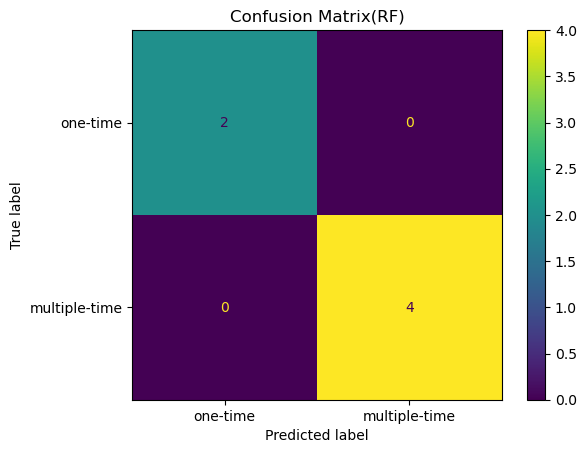

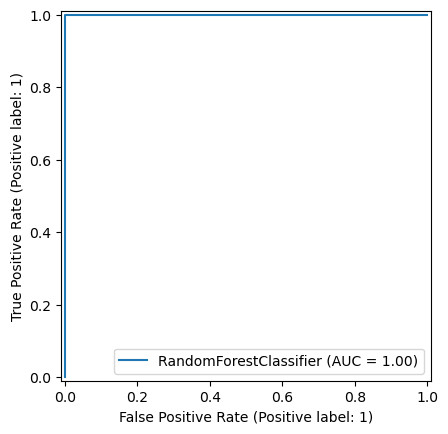

In [81]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve, RocCurveDisplay, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator( best_rf, X_test_scaled, y_test, display_labels=['one-time', 'multiple-time'] )
plt.title( 'Confusion Matrix(RF)' )
plt.show()

fpr, tpr, thresholds = roc_curve( y_test, y_pred_proba_rf )
roc_auc = auc( fpr, tpr )
RocCurveDisplay.from_estimator( best_rf, X_test_scaled, y_test )
plt.show()

# 3.4 Feature Importance Analysis

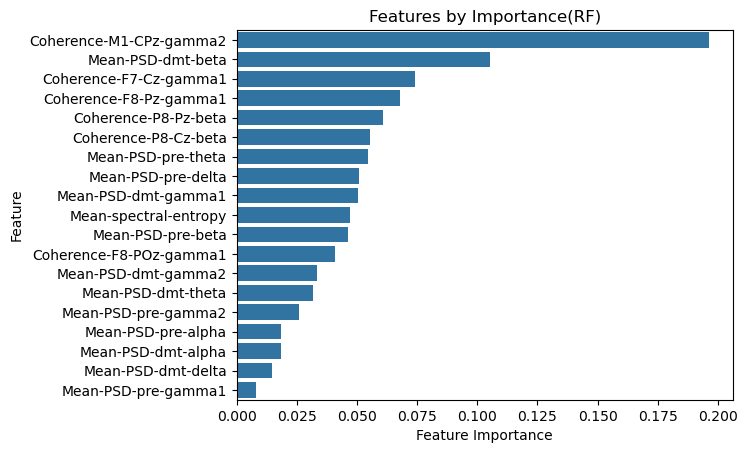

In [87]:
importances = best_rf.feature_importances_
feature_names = X.columns

feat_imp_df = pd.DataFrame( {"Feature": feature_names, "Feature Importance": importances} )
feat_imp_df = feat_imp_df.sort_values( 'Feature Importance', ascending=False )

sns.barplot( y='Feature', x='Feature Importance', data=feat_imp_df )
plt.title( 'Features by Importance(RF)' )
plt.show()